In [10]:
from pathlib import Path
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

random.seed(42)
np.random.seed(42)


In [18]:
NOTEBOOK_DIR = Path.cwd().resolve()
SEGMENTATION_ROOT = NOTEBOOK_DIR.parent
PROJECT_ROOT = SEGMENTATION_ROOT.parent
DATA_ROOT = SEGMENTATION_ROOT / "data"

candidate_roots = [
    DATA_ROOT / "EchoNet-Dynamic",
    DATA_ROOT / "echonet-dynamic",
    DATA_ROOT / "dynamic",
    DATA_ROOT,
]

dataset_root = None
for candidate in candidate_roots:
    if candidate.exists():
        dataset_root = candidate
        break

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SEGMENTATION_ROOT:", SEGMENTATION_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("dataset_root:", dataset_root)

PROJECT_ROOT: /Users/emirarslan/Downloads/lab task/echo-project
SEGMENTATION_ROOT: /Users/emirarslan/Downloads/lab task/echo-project/segmentation
DATA_ROOT: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data
dataset_root: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic


In [19]:
def find_first_match(root: Path, pattern: str):
    matches = sorted(root.rglob(pattern))
    return matches[0] if matches else None

filelist_path = find_first_match(dataset_root, "FileList.csv") if dataset_root else None
tracings_path = find_first_match(dataset_root, "VolumeTracings.csv") if dataset_root else None

videos_dir = None
if dataset_root is not None:
    possible_video_dirs = sorted([p for p in dataset_root.rglob("*") if p.is_dir() and p.name.lower() == "videos"])
    videos_dir = possible_video_dirs[0] if possible_video_dirs else None

print("FileList.csv:", filelist_path)
print("VolumeTracings.csv:", tracings_path)
print("Videos dir:", videos_dir)


FileList.csv: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic/FileList.csv
VolumeTracings.csv: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic/VolumeTracings.csv
Videos dir: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic/Videos


In [20]:
def print_tree(root: Path, max_depth: int = 2, max_entries_per_dir: int = 15):
    root = root.resolve()
    for current_root, dirs, files in os.walk(root):
        current_path = Path(current_root)
        depth = len(current_path.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "    " * depth
        print(f"{indent}{current_path.name}/")

        shown_files = sorted(files)[:max_entries_per_dir]
        for file_name in shown_files:
            print(f"{indent}    {file_name}")

        if len(files) > max_entries_per_dir:
            print(f"{indent}    ... ({len(files) - max_entries_per_dir} more files)")

print_tree(dataset_root, max_depth=2, max_entries_per_dir=10)


EchoNet-Dynamic/
    .DS_Store
    FileList.csv
    VolumeTracings.csv
    Videos/
        .DS_Store
        0X100009310A3BD7FC.avi
        0X1002E8FBACD08477.avi
        0X1005D03EED19C65B.avi
        0X10075961BC11C88E.avi
        0X10094BA0A028EAC3.avi
        0X100CF05D141FF143.avi
        0X100E3B8D3280BEC5.avi
        0X100E491B3CD58DE2.avi
        0X100F044876B98F90.avi
        ... (10021 more files)


In [21]:
file_df = pd.read_csv(filelist_path)

print("Shape:", file_df.shape)
print("\nColumns:")
print(file_df.columns.tolist())

display(file_df.head())

Shape: (10030, 9)

Columns:
['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames', 'Split']


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [25]:
print("Missing values per column:")
display(file_df.isna().sum().sort_values(ascending=False))

numeric_cols = file_df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

if numeric_cols:
    display(file_df[numeric_cols].describe().T)

Missing values per column:


FileName          0
EF                0
ESV               0
EDV               0
FrameHeight       0
FrameWidth        0
FPS               0
NumberOfFrames    0
Split             0
dtype: int64

Numeric columns: ['EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS', 'NumberOfFrames']


,count,mean,std,min,25%,50%,75%,max
EF,10030.0,55.748248,12.371483,6.907258,51.601387,59.209109,63.958740,96.967237
ESV,10030.0,43.427433,35.828098,4.350710,23.686339,33.596750,49.107316,612.489815
EDV,10030.0,91.324572,45.663554,12.618671,62.166669,82.084190,108.288686,695.036025
FrameHeight,10030.0,112.392423,16.040604,112.000000,112.000000,112.000000,112.000000,768.000000
FrameWidth,10030.0,112.547159,22.366033,112.000000,112.000000,112.000000,112.000000,1040.000000
FPS,10030.0,51.077767,6.238707,18.000000,50.000000,50.000000,50.000000,138.000000
NumberOfFrames,10030.0,176.533998,57.879145,28.000000,144.000000,171.000000,201.000000,1002.000000


In [26]:
display(file_df["FileName"].head(10))

sample_names = file_df["FileName"].dropna().astype(str).head(10).tolist()

for name in sample_names:
    print(name, "-> suffix:", Path(name).suffix)

0    0X100009310A3BD7FC
1    0X1002E8FBACD08477
2    0X1005D03EED19C65B
3    0X10075961BC11C88E
4    0X10094BA0A028EAC3
5    0X100CF05D141FF143
6    0X100E3B8D3280BEC5
7    0X100E491B3CD58DE2
8    0X100F044876B98F90
9    0X101026B90DAE7E95
Name: FileName, dtype: str

0X100009310A3BD7FC -> suffix: 
0X1002E8FBACD08477 -> suffix: 
0X1005D03EED19C65B -> suffix: 
0X10075961BC11C88E -> suffix: 
0X10094BA0A028EAC3 -> suffix: 
0X100CF05D141FF143 -> suffix: 
0X100E3B8D3280BEC5 -> suffix: 
0X100E491B3CD58DE2 -> suffix: 
0X100F044876B98F90 -> suffix: 
0X101026B90DAE7E95 -> suffix: 


In [27]:
trace_df = pd.read_csv(tracings_path)

print("Shape:", trace_df.shape)
print("\nColumns:")
print(trace_df.columns.tolist())

display(trace_df.head())


Shape: (425010, 6)

Columns:
['FileName', 'X1', 'Y1', 'X2', 'Y2', 'Frame']


,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


In [28]:
print(trace_df.dtypes)
print("\nMissing values per column:")
display(trace_df.isna().sum().sort_values(ascending=False))


FileName        str
X1          float64
Y1          float64
X2          float64
Y2          float64
Frame         int64
dtype: object

Missing values per column:


FileName    0
X1          0
Y1          0
X2          0
Y2          0
Frame       0
dtype: int64

In [29]:
traces_per_video = trace_df.groupby("FileName")["Frame"].nunique().sort_values()
display(traces_per_video.describe())

print("Videos with smallest number of traced frames:")
display(traces_per_video.head(10))

print("Videos with largest number of traced frames:")
display(traces_per_video.tail(10))

count    10025.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: Frame, dtype: float64

Videos with smallest number of traced frames:


FileName
0X100009310A3BD7FC.avi    2
0X601A0FE2BA2F9F68.avi    2
0X601B706CC84025BD.avi    2
0X602005216EB0FAB3.avi    2
0X6020D0C5C256684D.avi    2
0X602148BCD6E57281.avi    2
0X6022F9F42D2E8E06.avi    2
0X60232C8C3F8E33D5.avi    2
0X602624BAE73DF1D0.avi    2
0X6029ADEDDBD5A8E7.avi    2
Name: Frame, dtype: int64

Videos with largest number of traced frames:


FileName
0X385F55F9B1A71FD2.avi    2
0X38638F441D35402.avi     2
0X386444FB91940E3D.avi    2
0X386924A6B430342A.avi    2
0X3869ABCAB47DF8C9.avi    2
0X3869C8E146FBD123.avi    2
0X386DAB52217592A2.avi    2
0X386E38E6214B10A1.avi    2
0X3860318B66CC8557.avi    2
0XFEBEEFF93F6FEB9.avi     2
Name: Frame, dtype: int64

In [32]:
file_names = set(file_df["FileName"].astype(str))
trace_names_raw = set(trace_df["FileName"].astype(str))
trace_names = set(trace_df["FileName"].str.replace(".avi", "", regex=False).astype(str))

print("Unique names in FileList:", len(file_names))
print("Unique raw names in Tracings:", len(trace_names_raw))
print("Unique normalized names in Tracings:", len(trace_names))

print("Intersection after normalization:", len(file_names & trace_names))
print("In FileList but not in Tracings:", len(file_names - trace_names))
print("In Tracings but not in FileList:", len(trace_names - file_names))

missing_traces = sorted(file_names - trace_names)
extra_traces = sorted(trace_names - file_names)

print("\nMissing traces sample:", missing_traces[:10])
print("Extra traces sample:", extra_traces[:10])


Unique names in FileList: 10030
Unique raw names in Tracings: 10025
Unique normalized names in Tracings: 10025
Intersection after normalization: 10024
In FileList but not in Tracings: 6
In Tracings but not in FileList: 1

Missing traces sample: ['0X234005774F4CB5CD', '0X2DC68261CBCC04AE', '0X35291BE9AB90FB89', '0X5515B0BD077BE68A', '0X5DD5283AC43CCDD1', '0X6C435C1B417FDE8A']
Extra traces sample: ['0X4F8859C8AB4DA9CB']


In [31]:
video_files = sorted(videos_dir.glob("*.avi")) if videos_dir else []
video_stems = {p.stem for p in video_files}
video_names = {p.name for p in video_files}

print("Number of AVI files:", len(video_files))

csv_names = file_df["FileName"].astype(str)

missing_if_stem = [name for name in csv_names if name not in video_stems]
missing_if_full = [name for name in csv_names if name not in video_names]

print("Missing assuming FileName is stem:", len(missing_if_stem))
print("Missing assuming FileName is full filename:", len(missing_if_full))


Number of AVI files: 10030
Missing assuming FileName is stem: 0
Missing assuming FileName is full filename: 10030


In [33]:
print("Interpretation:")
print("- FileList uses stem names without .avi")
print("- VolumeTracings uses filenames with .avi")
print("- Video lookup should resolve FileName -> FileName.avi")
print("- A small number of videos are missing tracings and should be filtered out for segmentation training")


Interpretation:
- FileList uses stem names without .avi
- VolumeTracings uses filenames with .avi
- Video lookup should resolve FileName -> FileName.avi
- A small number of videos are missing tracings and should be filtered out for segmentation training


In [34]:
trace_df["FileStem"] = trace_df["FileName"].str.replace(".avi", "", regex=False)

traceable_video_names = sorted(set(file_df["FileName"].astype(str)) & set(trace_df["FileStem"].astype(str)))
missing_trace_video_names = sorted(set(file_df["FileName"].astype(str)) - set(trace_df["FileStem"].astype(str)))

print("Traceable videos:", len(traceable_video_names))
print("Missing-trace videos:", len(missing_trace_video_names))
print("Missing-trace video names:", missing_trace_video_names)

segmentation_candidates_df = file_df[file_df["FileName"].isin(traceable_video_names)].copy()
print("\nSegmentation candidate shape:", segmentation_candidates_df.shape)
display(segmentation_candidates_df.head())


Traceable videos: 10024
Missing-trace videos: 6
Missing-trace video names: ['0X234005774F4CB5CD', '0X2DC68261CBCC04AE', '0X35291BE9AB90FB89', '0X5515B0BD077BE68A', '0X5DD5283AC43CCDD1', '0X6C435C1B417FDE8A']

Segmentation candidate shape: (10024, 9)


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [35]:
def resolve_video_path(file_name: str, videos_dir: Path) -> Path:
    candidate_1 = videos_dir / file_name
    candidate_2 = videos_dir / f"{file_name}.avi"

    if candidate_1.exists():
        return candidate_1
    if candidate_2.exists():
        return candidate_2

    raise FileNotFoundError(f"Could not resolve video path for: {file_name}")

sample_file_name = str(file_df["FileName"].iloc[0])
print("Sample file name:", sample_file_name)
print("Resolved path:", resolve_video_path(sample_file_name, videos_dir))

Sample file name: 0X100009310A3BD7FC
Resolved path: /Users/emirarslan/Downloads/lab task/echo-project/segmentation/data/EchoNet-Dynamic/Videos/0X100009310A3BD7FC.avi


In [36]:
def read_video_metadata(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    return {
        "frame_count": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
    }

sample_video_path = resolve_video_path(sample_file_name, videos_dir)
metadata = read_video_metadata(sample_video_path)
metadata

{'frame_count': 174, 'fps': 50.0, 'width': 112, 'height': 112}

In [37]:
sampled_names = random.sample(file_df["FileName"].astype(str).tolist(), k=min(20, len(file_df)))

rows = []
for name in sampled_names:
    try:
        video_path = resolve_video_path(name, videos_dir)
        meta = read_video_metadata(video_path)
        meta["FileName"] = name
        rows.append(meta)
    except Exception as e:
        rows.append({
            "FileName": name,
            "frame_count": np.nan,
            "fps": np.nan,
            "width": np.nan,
            "height": np.nan,
            "error": str(e),
        })

sample_meta_df = pd.DataFrame(rows)
display(sample_meta_df.head())
display(sample_meta_df.describe(include="all"))


,frame_count,fps,width,height,FileName
0,227,50.0,112,112,0X2694F675274D5ED6
1,185,50.0,112,112,0X153A76426320A57B
2,195,53.0,112,112,0X461758F43BB8187
3,253,50.0,112,112,0X407AA1CC9F54562A
4,159,50.0,112,112,0X3BF45BED0E9423D0


,frame_count,fps,width,height,FileName
count,20.000000,20.000000,20.0,20.0,20
unique,NaN,NaN,NaN,NaN,20
top,NaN,NaN,NaN,NaN,0X2694F675274D5ED6
freq,NaN,NaN,NaN,NaN,1
mean,191.050000,50.400000,112.0,112.0,NaN
std,108.481129,1.273206,0.0,0.0,NaN
min,98.000000,50.000000,112.0,112.0,NaN
25%,145.000000,50.000000,112.0,112.0,NaN
50%,171.500000,50.000000,112.0,112.0,NaN
75%,195.750000,50.000000,112.0,112.0,NaN


In [38]:
def collect_video_metadata(file_names, videos_dir):
    rows = []
    for i, name in enumerate(file_names, start=1):
        try:
            video_path = resolve_video_path(str(name), videos_dir)
            meta = read_video_metadata(video_path)
            rows.append({
                "FileName": str(name),
                **meta,
                "exists": True,
                "error": None,
            })
        except Exception as e:
            rows.append({
                "FileName": str(name),
                "frame_count": np.nan,
                "fps": np.nan,
                "width": np.nan,
                "height": np.nan,
                "exists": False,
                "error": str(e),
            })

        if i % 500 == 0:
            print(f"Processed {i}/{len(file_names)} videos")

    return pd.DataFrame(rows)

video_meta_df = collect_video_metadata(file_df["FileName"], videos_dir)
display(video_meta_df.head())


Processed 500/10030 videos
Processed 1000/10030 videos
Processed 1500/10030 videos
Processed 2000/10030 videos
Processed 2500/10030 videos
Processed 3000/10030 videos
Processed 3500/10030 videos
Processed 4000/10030 videos
Processed 4500/10030 videos
Processed 5000/10030 videos
Processed 5500/10030 videos
Processed 6000/10030 videos
Processed 6500/10030 videos
Processed 7000/10030 videos
Processed 7500/10030 videos
Processed 8000/10030 videos
Processed 8500/10030 videos
Processed 9000/10030 videos
Processed 9500/10030 videos
Processed 10000/10030 videos


,FileName,frame_count,fps,width,height,exists,error
0,0X100009310A3BD7FC,174,50.0,112,112,True,None
1,0X1002E8FBACD08477,215,50.0,112,112,True,None
2,0X1005D03EED19C65B,104,50.0,112,112,True,None
3,0X10075961BC11C88E,122,55.0,112,112,True,None
4,0X10094BA0A028EAC3,207,52.0,112,112,True,None


In [39]:
print("Videos successfully opened:", video_meta_df["exists"].sum())
print("Videos failed:", (~video_meta_df["exists"]).sum())

display(video_meta_df[["frame_count", "fps", "width", "height"]].describe())


Videos successfully opened: 10030
Videos failed: 0


,frame_count,fps,width,height
count,10030.000000,10030.000000,10030.0,10030.0
mean,176.533998,51.077767,112.0,112.0
std,57.879145,6.238707,0.0,0.0
min,28.000000,18.000000,112.0,112.0
25%,144.000000,50.000000,112.0,112.0
50%,171.000000,50.000000,112.0,112.0
75%,201.000000,50.000000,112.0,112.0
max,1002.000000,138.000000,112.0,112.0


In [48]:
merged_df = file_df.merge(video_meta_df, on="FileName", how="left", suffixes=("_csv", "_video"))

comparison_cols = [
    ("FPS", "fps"),
    ("NumberOfFrames", "frame_count"),
    ("FrameHeight", "height"),
    ("FrameWidth", "width"),
]

for col_csv, col_video in comparison_cols:
    print(f"\nComparing {col_csv} vs {col_video}")
    diff = merged_df[col_csv] - merged_df[col_video]
    print(diff.describe())



Comparing FPS vs fps
count    10030.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

Comparing NumberOfFrames vs frame_count
count    10030.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

Comparing FrameHeight vs height
count    10030.000000
mean         0.392423
std         16.040604
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        656.000000
dtype: float64

Comparing FrameWidth vs width
count    10030.000000
mean         0.547159
std         22.366033
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        928.000000
dtype: float64


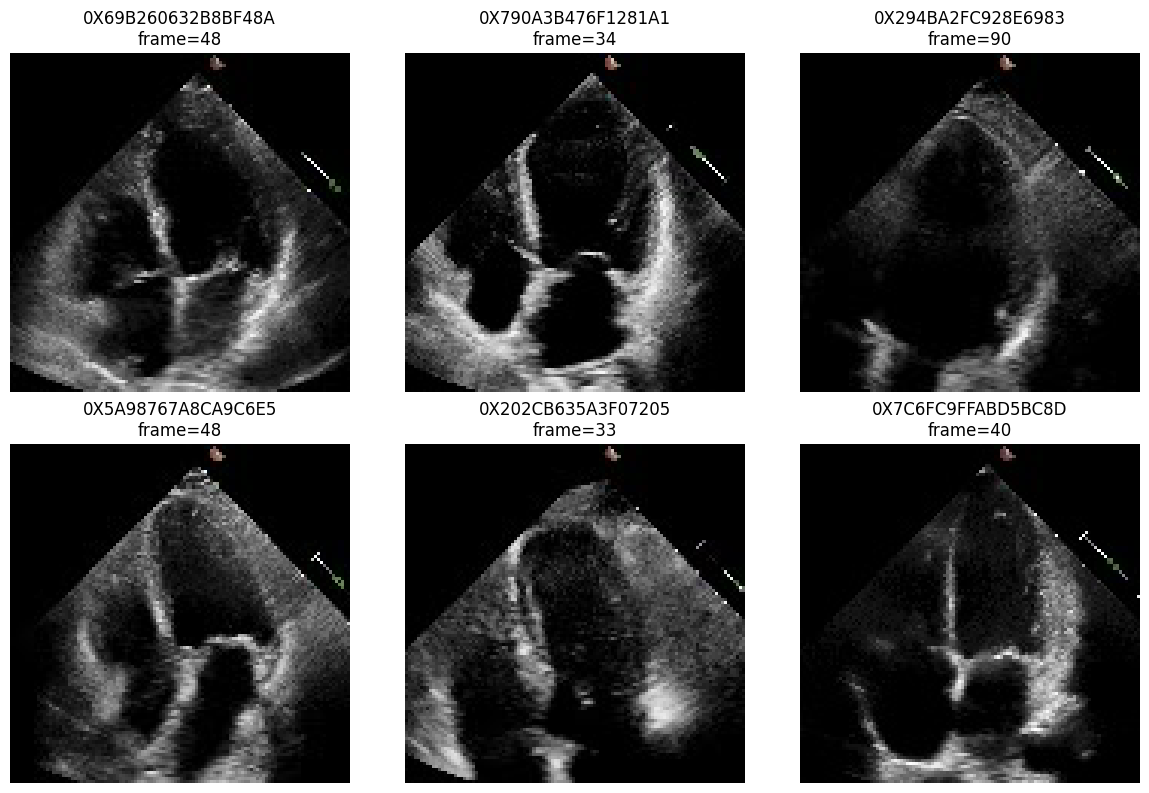

In [49]:
def load_frame(video_path: Path, frame_index: int):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise ValueError(f"Could not read frame {frame_index} from {video_path}")

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return frame

sample_trace_names = random.sample(traceable_video_names, k=min(6, len(traceable_video_names)))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, name in zip(axes, sample_trace_names):
    rows = trace_df[trace_df["FileStem"] == name]
    sample_frame_idx = int(rows["Frame"].iloc[0])

    video_path = resolve_video_path(name, videos_dir)
    frame = load_frame(video_path, sample_frame_idx)

    ax.imshow(frame)
    ax.set_title(f"{name}\nframe={sample_frame_idx}")
    ax.axis("off")

for ax in axes[len(sample_trace_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [50]:
summary = {
    "n_rows_filelist": len(file_df),
    "n_rows_tracings": len(trace_df),
    "n_unique_videos_in_filelist": file_df["FileName"].nunique(),
    "n_unique_videos_in_tracings_raw": trace_df["FileName"].nunique(),
    "n_unique_videos_in_tracings_normalized": trace_df["FileStem"].nunique(),
    "n_traceable_videos": len(traceable_video_names),
    "n_missing_trace_videos": len(missing_trace_video_names),
    "n_video_files_found": len(video_files),
    "n_successfully_opened_videos": int(video_meta_df["exists"].sum()),
    "split_counts": file_df["Split"].value_counts().to_dict(),
}

summary


{'n_rows_filelist': 10030,
 'n_rows_tracings': 425010,
 'n_unique_videos_in_filelist': 10030,
 'n_unique_videos_in_tracings_raw': 10025,
 'n_unique_videos_in_tracings_normalized': 10025,
 'n_traceable_videos': 10024,
 'n_missing_trace_videos': 6,
 'n_video_files_found': 10030,
 'n_successfully_opened_videos': 10030,
 'split_counts': {'TRAIN': 7465, 'VAL': 1288, 'TEST': 1277}}